即席麺とうどん・そうめん・そばの、日本から各国への販売実績金額の相関

In [1]:
conda install xlrd

3 channel Terms of Service accepted
Retrieving notices: done
Channels:
 - defaults
Platform: win-64
Solving environment: done

# All requested packages already installed.


Note: you may need to restart the kernel to use updated packages.




==> WARNING: A newer version of conda exists. <==
    current version: 26.1.1
    latest version: 26.5.3

Please update conda by running

    $ conda update -n base -c defaults conda




In [2]:
import pandas as pd
df=pd.read_excel(r'C:\Users\natsu\myworks_for_GitHub\Python-machine-learning-study-log\opendata_analysis\datafiles\k002-2022-00-b025.xls')

In [3]:
display(df.head(10))

,報告書名：農林水産物品目別実績（輸出）,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9,Unnamed: 10
0,年次：令.４（２０２２）,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,月次：年計,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,即席麺、うどん・そうめん・そば,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,国 名,即席麺,NaN,NaN,NaN,NaN,うどん・そうめん・そば,NaN,NaN,NaN,NaN
6,NaN,第一単位,第一数量,第二単位,第二数量,金額（千円）,第一単位,第一数量,第二単位,第二数量,金額（千円）
7,世界,NaN,0,KG,12698888,10047706,NaN,0,KG,11989825,4196139
8,大韓民国,NaN,0,KG,325081,298742,NaN,0,KG,362861,160653
9,中華人民共和国,NaN,0,KG,445577,499309,NaN,0,KG,1146219,560262


In [4]:
df2=df.drop(index=range(0,8),axis=0)   #世界全体のデータは国のデータと並列して扱いづらいので除く

col=['Unnamed: 1','Unnamed: 2','Unnamed: 3','Unnamed: 4','Unnamed: 6','Unnamed: 7','Unnamed: 8','Unnamed: 9']
df2=df2.drop(columns=col,axis=1)

In [5]:
df2 = df2.rename(columns={'報告書名：農林水産物品目別実績（輸出）':'国名'})
df2 = df2.rename(columns={'Unnamed: 5':'即席麺　売上金額(千円)'})
df2 = df2.rename(columns={'Unnamed: 10':'うどん・そば・そうめん　売上金額(千円)'})
df2=df2.set_index('国名')

In [6]:
display(df2.head(10))

,即席麺 売上金額(千円),うどん・そば・そうめん 売上金額(千円)
国名,,
大韓民国,298742,160653
中華人民共和国,499309,560262
台湾,1015745,284189
モンゴル,9960,7218
香港,2793666,830895
ベトナム,506518,77954
タイ,202489,108394
シンガポール,356483,197827
マレーシア,153713,65506


In [7]:
tmp=df2.isnull()
tmp.sum()

即席麺　売上金額(千円)             8
うどん・そば・そうめん　売上金額(千円)    11
dtype: int64

In [8]:
df2.count()

即席麺　売上金額(千円)            65
うどん・そば・そうめん　売上金額(千円)    62
dtype: int64

In [9]:
df3=df2.fillna(df2.mean())

C:\Users\natsu\AppData\Local\Temp\ipykernel_21368\2307020088.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df3=df2.fillna(df2.mean())


<Axes: xlabel='即席麺\u3000売上金額(千円)', ylabel='うどん・そば・そうめん\u3000売上金額(千円)'>

c:\Users\natsu\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 21363 (\N{CJK UNIFIED IDEOGRAPH-5373}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\natsu\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 24109 (\N{CJK UNIFIED IDEOGRAPH-5E2D}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\natsu\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 40634 (\N{CJK UNIFIED IDEOGRAPH-9EBA}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\natsu\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 12288 (\N{IDEOGRAPHIC SPACE}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\natsu\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 22770 (\N{CJK UNIFIED IDEOGRAPH-58F2}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
c:\Users\natsu\anaconda3\Lib\site-packages\IPython\core\events.py:82: UserWarni

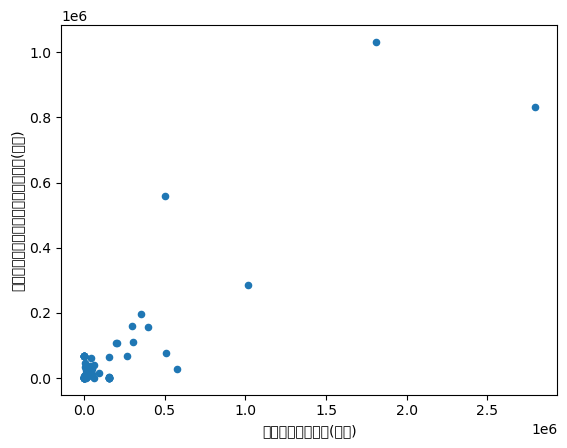

In [10]:
df3.plot(kind='scatter',x='即席麺　売上金額(千円)',y='うどん・そば・そうめん　売上金額(千円)')

In [11]:
x=df3[['即席麺　売上金額(千円)']]
t=df3[['うどん・そば・そうめん　売上金額(千円)']]

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler


#標準化
sc_model_x=StandardScaler()
sc_model_x.fit(x)

sc_model_y=StandardScaler()
sc_model_y.fit(t)

sc_x=sc_model_x.transform(x)
sc_y=sc_model_y.transform(t)


In [13]:
#単回帰分析の実行
model=LinearRegression()
model.fit(sc_x,sc_y)

print(model.score(x,t))

-1.0164999076608083


c:\Users\natsu\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2742: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [14]:
print(df3.corr())

                      即席麺　売上金額(千円)  うどん・そば・そうめん　売上金額(千円)
即席麺　売上金額(千円)              1.000000              0.881478
うどん・そば・そうめん　売上金額(千円)      0.881478              1.000000
